**Entrenamiento** redes neuronales con Keras

En esta primera parte, vamos a utilizar una red neuronal para clasificar imágenes de prendas de ropa. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es Fashion MNIST, un problema sencillo con imágenes pequeñas de ropa, pero más interesante que el dataset de MNIST. Puedes consultar más información sobre el dataset en [este enlace](https://github.com/zalandoresearch/fashion-mnist).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas cells si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados** (por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch).

In [1]:
import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np

Primero, vamos a obtener los datos. Por suerte para nosotros, estos pueden ser descargados directamente desde Keras, por lo que no tendremos que preocuparnos de tratar con ficheros.

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Acto seguido, normalizamos esos datos de manera similar a como hemos visto con MNIST, obteniendo valores entre 0 y 1. Este paso es muy importante para el correcto funcionamiento de nuestra red.

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1 ** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [11]:
# Mostramos el número de imágenes y su tamaño para el conjunto de entrenamiento
print(f"Número de imágenes de training: {x_train.shape[0]}")
print(f"Tamaño de cada imagen de training: {x_train.shape[1]}x{x_train.shape[2]} píxeles")

# Mostramos el número de imágenes y su tamaño para el conjunto de test
print(f"\nNúmero de imágenes de test: {x_test.shape[0]}")
print(f"Tamaño de cada imagen de test: {x_test.shape[1]}x{x_test.shape[2]} píxeles")

# También mostramos las shapes completas
print(f"\nShape de x_train: {x_train.shape}")
print(f"Shape de x_test: {x_test.shape}")

Número de imágenes de training: 60000
Tamaño de cada imagen de training: 28x28 píxeles
Número de imágenes de test: 10000
Tamaño de cada imagen de test: 28x28 píxeles

Shape de x_train: (60000, 28, 28)
Shape de x_test: (10000, 28, 28)


Hay **60.000 imágenes de training** y **10.000 imágenes de test**. Cada imagen tiene un tamaño de **28x28 píxeles** (escala de grises, 1 canal).

**Pregunta 1.2 ** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

In [5]:
# Exploración de los datos de entrada (x)
print("=== Exploración de x_train ===")
print(f"Tipo de dato: {x_train.dtype}")
print(f"Valor mínimo: {x_train.min()}")
print(f"Valor máximo: {x_train.max()}")
print(f"Ejemplo de un píxel (primer píxel de la primera imagen): {x_train[0][0][0]}")
print(f"Shape de una imagen individual: {x_train[0].shape}")

print("\n=== Exploración de y_train ===")
print(f"Tipo de dato: {y_train.dtype}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Valores únicos (clases): {np.unique(y_train)}")
print(f"Número de clases: {len(np.unique(y_train))}")
print(f"Primeras 20 etiquetas: {y_train[:20]}")

# Nombres de las clases de Fashion MNIST
class_names = ['Camiseta/top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

# Distribución de clases en el conjunto de entrenamiento
print("\n=== Distribución de clases en training ===")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  Clase {i} ({name}): {count} imágenes")

=== Exploración de x_train ===
Tipo de dato: float64
Valor mínimo: 0.0
Valor máximo: 1.0
Ejemplo de un píxel (primer píxel de la primera imagen): 0.0
Shape de una imagen individual: (28, 28)

=== Exploración de y_train ===
Tipo de dato: uint8
Shape de y_train: (60000,)
Valores únicos (clases): [0 1 2 3 4 5 6 7 8 9]
Número de clases: 10
Primeras 20 etiquetas: [9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4]

=== Distribución de clases en training ===
  Clase 0 (Camiseta/top): 6000 imágenes
  Clase 1 (Pantalón): 6000 imágenes
  Clase 2 (Jersey): 6000 imágenes
  Clase 3 (Vestido): 6000 imágenes
  Clase 4 (Abrigo): 6000 imágenes
  Clase 5 (Sandalia): 6000 imágenes
  Clase 6 (Camisa): 6000 imágenes
  Clase 7 (Zapatilla): 6000 imágenes
  Clase 8 (Bolso): 6000 imágenes
  Clase 9 (Bota): 6000 imágenes


Cada ejemplo del dataset consiste en una **imagen en escala de grises de 28x28 píxeles** que representa una prenda de ropa. Los valores de cada píxel están normalizados entre 0.0 y 1.0 (originalmente de 0 a 255), donde 0 representa negro y 1 representa blanco.

La variable **y** contiene las **etiquetas (labels)** de cada imagen, es decir, un número entero entre 0 y 9 que indica la clase de prenda a la que pertenece la imagen. Hay 10 clases en total: 0=Camiseta/top, 1=Pantalón, 2=Jersey, 3=Vestido, 4=Abrigo, 5=Sandalia, 6=Camisa, 7=Zapatilla, 8=Bolso, 9=Bota.

Vamos a **visualizar** una imagen de ejemplo. Prueba tu mismo a cambiar la imagen en uso para explorar el dataset visualmente ejecutando el siguiente código:

In [6]:
def visualize_example(x):
    plt.figure()
    plt.imshow(x)
    plt.colorbar()
    plt.grid(False)
    plt.show()

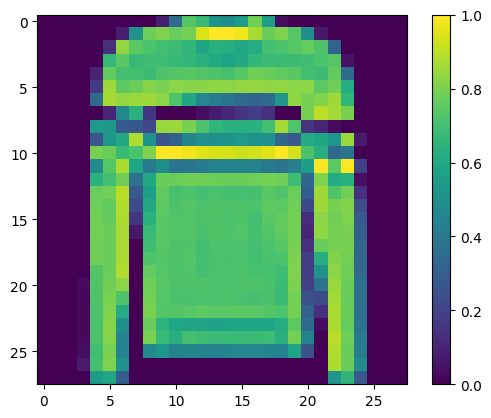

In [7]:
visualize_example(x_train[5])

## 2. Entrenamiento de una red neuronal simple

**Pregunta 2 **. Utilizando Keras, y preparando los datos de X e y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de Fashion MNIST con las siguientes características:

* Dos hidden layers de tamaños 128 y 64, utilizando unidades **sigmoid**
* Optimizador **sgd**.
* Durante el entrenamiento, la red tiene que mostrar resultados de **loss** y **accuracy** por cada epoch.
* La red debe entrenar durante **20 epochs** y batch size de **64**.
* La última capa debe de ser una capa **softmax**.

Tu red tendría que ser capaz de superar fácilmente 60% de accuracy.

In [8]:
# --- Preparación de los datos ---
# Aplanamos (flatten) las imágenes de 28x28 a vectores de 784 elementos,
# ya que las capas Dense requieren entrada unidimensional.
x_train_flat = x_train.reshape(x_train.shape[0], 28 * 28)  # (60000, 784)
x_test_flat = x_test.reshape(x_test.shape[0], 28 * 28)     # (10000, 784)

print(f"Shape de x_train_flat: {x_train_flat.shape}")
print(f"Shape de x_test_flat: {x_test_flat.shape}")

# --- Definición del modelo ---
# Creamos un modelo secuencial con:
# - Capa de entrada: 784 neuronas (28*28 píxeles aplanados)
# - Primera hidden layer: 128 neuronas con activación sigmoid
# - Segunda hidden layer: 64 neuronas con activación sigmoid
# - Capa de salida: 10 neuronas con activación softmax (una por clase)
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(784,)),  # Primera capa oculta: 128 neuronas, sigmoid
    Dense(64, activation='sigmoid'),                        # Segunda capa oculta: 64 neuronas, sigmoid
    Dense(10, activation='softmax')                         # Capa de salida: 10 clases, softmax
])

# --- Compilación del modelo ---
# Usamos el optimizador SGD (Stochastic Gradient Descent).
# La función de pérdida es sparse_categorical_crossentropy porque las etiquetas
# son enteros (no están codificadas en one-hot).
# Indicamos que queremos monitorizar la métrica 'accuracy'.
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen de la arquitectura del modelo
model.summary()

# --- Entrenamiento del modelo ---
# Entrenamos durante 20 epochs con batch size de 64.
# verbose=1 muestra el progreso del entrenamiento con loss y accuracy por cada epoch.
history = model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    verbose=1
)

Shape de x_train_flat: (60000, 784)
Shape de x_test_flat: (10000, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2600 - loss: 2.2747
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5798 - loss: 1.9887
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6100 - loss: 1.5535
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6554 - loss: 1.2508
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6801 - loss: 1.0780
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7091 - loss: 0.9539
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7228 - loss: 0.8705
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7343 - loss: 0.8070
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7391 - loss: 0.7631
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7475 - loss: 0.7249
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7524 - loss: 0.6958
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

## 3. Evaluación del modelo en datos de test

Una vez hemos entrenado nuestro modelo, vamos a evaluarlo en los datos de test de Fashion MNIST.

**Pregunta 3.1 ***. Utilizando el modelo recién entrenado, obtener la accuracy resultante en el dataset de test.

In [9]:
# Evaluamos el modelo en el conjunto de test utilizando model.evaluate.
# Este método devuelve la loss y las métricas configuradas (en este caso, accuracy).
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=1)

print(f"\nLoss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7946 - loss: 0.5711

Loss en test: 0.5749
Accuracy en test: 0.7912 (79.12%)


**Pregunta 3.2 ***. Utilizando el método **predict** de Keras, realizar predicciones para los datos de test. Por cada predicción resultante, ¿qué significan los números que obtenemos al hacer predict? ¿Cómo podemos obtener el valor de la clase resultante? (recordar que estamos utilizando una capa softmax para clasificar).

In [10]:
# Realizamos predicciones sobre el conjunto de test
predictions = model.predict(x_test_flat)

# Mostramos la predicción para el primer ejemplo de test
print("Predicción para la primera imagen de test:")
print(predictions[0])
print(f"\nLa predicción es un vector de {len(predictions[0])} elementos (uno por clase).")
print(f"Cada valor representa la probabilidad de que la imagen pertenezca a esa clase.")
print(f"La suma de todas las probabilidades es: {np.sum(predictions[0]):.4f} (≈ 1.0)")

# Para obtener la clase predicha, seleccionamos el índice con la probabilidad más alta
# usando np.argmax
predicted_class = np.argmax(predictions[0])
print(f"\nClase predicha (argmax): {predicted_class}")
print(f"Probabilidad de la clase predicha: {predictions[0][predicted_class]:.4f}")
print(f"Clase real: {y_test[0]}")

# Mostramos las predicciones para los primeros 5 ejemplos
print("\n=== Predicciones para los primeros 5 ejemplos ===")
class_names = ['Camiseta/top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

for i in range(5):
    pred_class = np.argmax(predictions[i])
    confidence = predictions[i][pred_class]
    real_class = y_test[i]
    match = '✓' if pred_class == real_class else '✗'
    print(f"  Ejemplo {i}: Predicho={class_names[pred_class]} ({confidence:.2%}), "
          f"Real={class_names[real_class]} {match}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicción para la primera imagen de test:
[4.39696159e-05 1.44910766e-04 2.43909817e-04 2.37932909e-04
 1.64615587e-04 1.58427685e-01 1.25049613e-04 2.85468191e-01
 1.37318475e-02 5.41411996e-01]

La predicción es un vector de 10 elementos (uno por clase).
Cada valor representa la probabilidad de que la imagen pertenezca a esa clase.
La suma de todas las probabilidades es: 1.0000 (≈ 1.0)

Clase predicha (argmax): 9
Probabilidad de la clase predicha: 0.5414
Clase real: 9

=== Predicciones para los primeros 5 ejemplos ===
  Ejemplo 0: Predicho=Bota (54.14%), Real=Bota ✓
  Ejemplo 1: Predicho=Jersey (77.02%), Real=Jersey ✓
  Ejemplo 2: Predicho=Pantalón (99.47%), Real=Pantalón ✓
  Ejemplo 3: Predicho=Pantalón (99.06%), Real=Pantalón ✓
  Ejemplo 4: Predicho=Camisa (49.87%), Real=Camisa ✓


Los números que obtenemos al hacer `predict` son las **probabilidades** de que la imagen pertenezca a cada una de las 10 clases. Esto es así porque la última capa de nuestra red utiliza la función de activación **softmax**, que transforma las salidas de la red en una distribución de probabilidad (todos los valores son positivos y suman 1.0).

Para obtener la **clase resultante** (la predicción final), debemos seleccionar el **índice con la probabilidad más alta**, lo cual se hace con la función `np.argmax()`. Por ejemplo, si el vector de probabilidades es `[0.01, 0.02, 0.85, 0.03, ...]`, `np.argmax` devolvería `2`, indicando que la red predice la clase 2 (Jersey) con un 85% de confianza.